In [1]:
import scanpy as sc
import anndata  as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os.path as op
import os
results_dir = './results'

## Additional annotation methods

We load the data we previously annotated for further downstream analysis.

In [3]:
adata = sc.read_h5ad(op.join(results_dir, 'adata_qc.h5ad'))

AnnData object with n_obs × n_vars = 2897 × 16975
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'manual_celltype_labels'
    var: 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dendrogram_manual_celltype_labels', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'manual_celltype_labels_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distanc

## Celltypist

In [5]:

import celltypist
from celltypist import models
models.download_models(model = 'Immune_All_Low.pkl', force_update = True)
model = models.Model.load(model = '/home/bionets-og86asub/.celltypist/data/models/Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

/home/bionets-og86asub/Documents/teaching/compbiol-course/compbiol/htseq/1-intro-rnaseq/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /home/bionets-og86asub/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl
🔬 Input data has 2897 cells and 16975 genes
🔗 Matching reference genes in the model
🧬 5106 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [ ]:
## Look at the prediction labels
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
CAATACGAGACGCCAA,Non-classical monocytes,0,Non-classical monocytes
AACGTCACAACACGAG,Classical monocytes,2,Classical monocytes
GAAGGACAGGAATTAC,MAIT cells,3,Tem/Trm cytotoxic T cells
CCACGTTAGTCCCAAT,pDC,4,pDC
TGGAGAGCATGTGACT,Age-associated B cells,5,Memory B cells
...,...,...,...
TGTAAGCTCGTGGGTC,Tem/Effector helper T cells,18,Tcm/Naive helper T cells
TGGTACAGTCATCAGT,Tcm/Naive helper T cells,18,Tcm/Naive helper T cells
AGCGTATGTGTAGTGG,DC2,51,DC2
AAAGGGCTCGCCTTGT,Classical monocytes,15,Classical monocytes


In [11]:
adata.obs['celltypist_majority_labels'] = predictions.predicted_labels['majority_voting'].values

## Verify/analyse the predictions made by celltyist vs the manual annotaion
Here, we can see some inconsistencies between the manual annotation we made and the celltypist annotation, potentially, we made some mistakes when deciding which cells where which. T cells are annotated at a more granular level in celltypist than the ones we made. At this point we can go back and harmonize the labels manually.

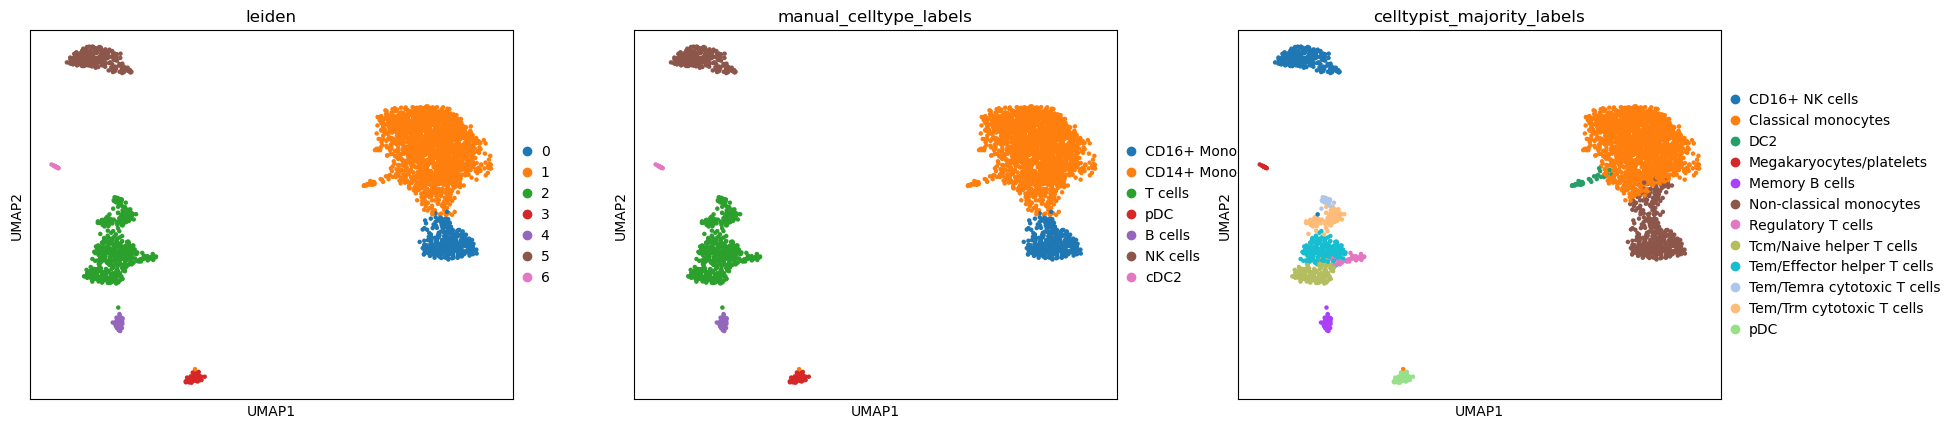

In [13]:
sc.pl.umap(adata, color = ['leiden', 'manual_celltype_labels', 'celltypist_majority_labels'])

## Decoupler

Decoupler uses overrepresentation analysis to score a set of genes against the marker genes from the clusters to assign the celltypes. After selecting our set of marker genes, we can proceed similarly than with manual celltype annotation. The difference is that instead of looking at individual genes, we get a score for groups of genes to understand the cluster gene expression at a more holistic level.

In [14]:
import decoupler as dc

markers = dc.op.resource("PanglaoDB", organism="human")

# Filter by canonical_marker and human
markers = markers[
    markers["human"].astype(bool)
    & markers["canonical_marker"].astype(bool)
    & (markers["human_sensitivity"].astype(float) > 0.5)
]

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

# Format
markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]
markers


,source,target
,,
18,Pulmonary alveolar type II cells,ABCA3
90,Enterocytes,ACSL5
105,Smooth muscle cells,ACTA2
113,Smooth muscle cells,ACTG2
114,Myoepithelial cells,ACTG2
...,...,...
8092,Endothelial cells,VWF
8101,Luminal epithelial cells,WFDC2
8102,Ductal cells,WFDC2


### Score the cells and extract the score matrix from the object
Here we just plot an example from the natural killer cells and see that these correspond with both the manual annnotation and the celltypist annotation. On the umap we color the points, and we can also look at the violin plot to see on a cluster basis which cluster obtains the highest score for the natural killer cell gene signature. 

In [ ]:
dc.mt.ulm(data=adata, net=markers, tmin=3)
score = dc.pp.get_obsm(adata, key="score_ulm")


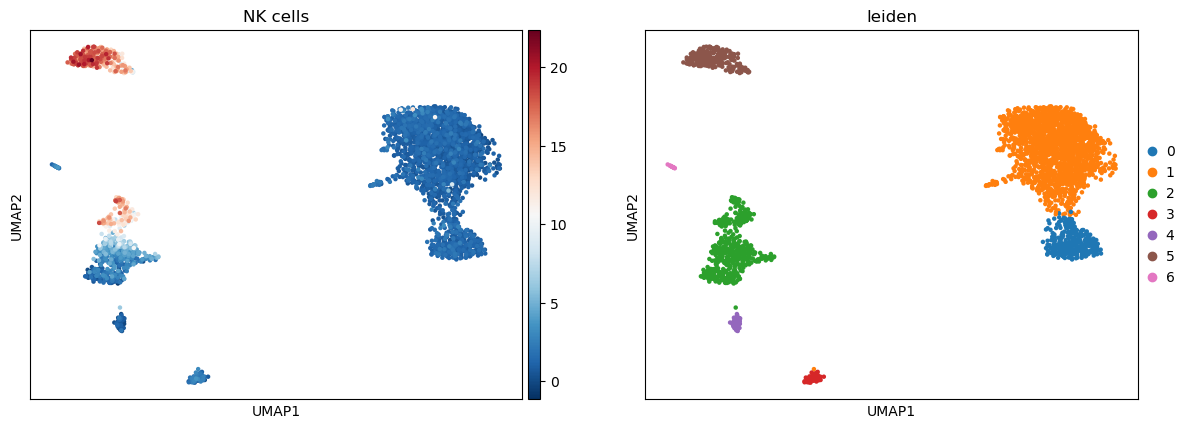

In [22]:
sc.pl.umap(score, color=["NK cells", "leiden"], cmap="RdBu_r")


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

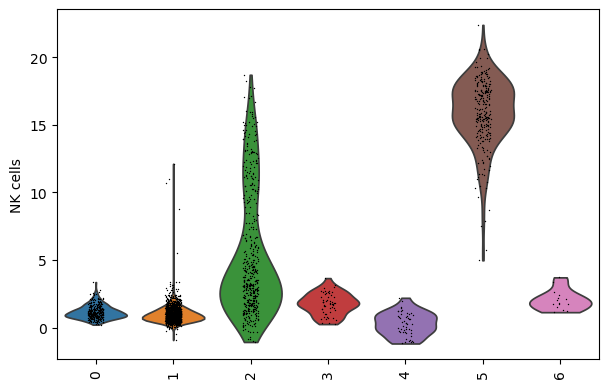

In [23]:
sc.pl.violin(score, keys=["NK cells"], groupby="leiden", rotation=90)
